In [1]:
# ==========================================
# 1. INSTALL & SETUP
# ==========================================
!pip install -q sentence-transformers datasets scipy

import json
import torch
import numpy as np
from scipy import stats
from sentence_transformers import SentenceTransformer, util
from datasets import Dataset
from google.colab import userdata
from huggingface_hub import login

# Setup Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Login (Optional: Only needed if your models are Private/Gated)
try:
    login(token=userdata.get('HF_TOKEN'), add_to_git_credential=True)
except:
    print("HF Token not found in secrets or login skipped. Ensure models are public.")

Using device: cuda


In [2]:
# ==========================================
# 2. PREPARE DATA (Exactly as in Training)
# ==========================================
!git lfs install
!git clone https://huggingface.co/datasets/sartajekram/BanglaRQA

Git LFS initialized.
Cloning into 'BanglaRQA'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 77 (delta 19), reused 0 (delta 0), pack-reused 43 (from 1)
Unpacking objects: 100% (77/77), 1.00 MiB | 4.59 MiB/s, done.


In [3]:
def load_and_parse_banglarqa(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    examples = []
    for article in data['data']:
        passage_id = article['passage_id']
        context = article['context']
        for qa in article['qas']:
            example = {
                'passage_id': passage_id,
                'context': context,
                'question_id': qa['question_id'],
                'question_text': qa['question_text'],
                'is_answerable': qa['is_answerable']
            }
            examples.append(example)
    return examples

# Load Data
print("Loading and processing dataset...")
train_raw = load_and_parse_banglarqa('BanglaRQA/Train.json')
val_raw = load_and_parse_banglarqa('BanglaRQA/Validation.json')
test_raw = load_and_parse_banglarqa('BanglaRQA/Test.json')

# Create offset for IDs like in training to match corpus ID generation
train_len = len(train_raw) + len(val_raw)

# Process Test Set
test_ds = Dataset.from_list(test_raw)
test_dataset = test_ds.filter(lambda example: example["is_answerable"] == "1")
test_dataset = test_dataset.rename_column("question_text", "anchor")
test_dataset = test_dataset.rename_column("context", "positive")
test_dataset = test_dataset.add_column("id", range(train_len, train_len + len(test_dataset)))

# Prepare Retrieval Objects
# 1. Corpus (using row ID as doc_id)
corpus = dict(zip(test_dataset["id"], test_dataset["positive"]))

# 2. Queries
queries = dict(zip(test_dataset["id"], test_dataset["anchor"]))

# 3. Relevant Docs Mapping
relevant_docs = {}
for row in test_dataset:
    q_id = row['id']
    passage_id = row['passage_id']
    if q_id not in relevant_docs:
        relevant_docs[q_id] = set()
    # Find all docs in test set that share the passage_id
    matching_ids = [row_inner['id'] for row_inner in test_dataset if row_inner['passage_id'] == passage_id]
    relevant_docs[q_id].update(matching_ids)

print(f"Test Set Ready: {len(queries)} queries against {len(corpus)} documents.")

Loading and processing dataset...


Filter:   0%|          | 0/1493 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1124 [00:00<?, ? examples/s]

Test Set Ready: 1124 queries against 1124 documents.


In [4]:
# ==========================================
# 3. HELPER FUNCTION: Per-Query Scoring
# ==========================================
def get_per_query_ndcg(model_id, queries, corpus, relevant_docs, k=10, batch_size=32):
    print(f"\nLoading Model: {model_id}...")
    model = SentenceTransformer(model_id, device=device)

    query_ids = list(queries.keys())
    query_texts = [queries[qid] for qid in query_ids]

    corpus_ids = list(corpus.keys())
    corpus_texts = [corpus[cid] for cid in corpus_ids]

    print("Encoding Queries and Corpus...")
    q_embs = model.encode(query_texts, batch_size=batch_size, convert_to_tensor=True, show_progress_bar=True)
    c_embs = model.encode(corpus_texts, batch_size=batch_size, convert_to_tensor=True, show_progress_bar=True)

    print("Computing Similarities...")
    cos_scores = util.cos_sim(q_embs, c_embs).cpu() # Move to CPU

    scores_list = []

    for i, qid in enumerate(query_ids):
        true_doc_ids = relevant_docs.get(qid, set())

        if not true_doc_ids:
            scores_list.append(0.0)
            continue

        # Get Top K
        top_k_vals, top_k_ind = torch.topk(cos_scores[i], k=k)
        top_k_ind = top_k_ind.tolist()

        # DCG
        dcg = 0.0
        for rank, idx in enumerate(top_k_ind):
            retrieved_id = corpus_ids[idx]
            if retrieved_id in true_doc_ids:
                dcg += 1.0 / np.log2(rank + 2)

        # IDCG
        idcg = 0.0
        for rank in range(min(len(true_doc_ids), k)):
            idcg += 1.0 / np.log2(rank + 2)

        ndcg = dcg / idcg if idcg > 0 else 0.0
        scores_list.append(ndcg)

    # Clear GPU memory
    del model
    del q_embs
    del c_embs
    torch.cuda.empty_cache()

    return scores_list

In [5]:
# ==========================================
# 4. RUN EVALUATION
# ==========================================

# !!! REPLACE THESE WITH YOUR ACTUAL HUGGING FACE MODEL IDs !!!
MODELS_TO_TEST = {
    # "Label in Paper": "HuggingFace_Model_ID",
    "DistilUSE-FT": "Kowshik24/bangla-sentence-transformer-ft-matryoshka-distiluse-base-multilingual-cased-v1", # Example
    "Shihab17-FT": "Kowshik24/bangla-sentence-transformer-ft-matryoshka",     # Example
    "MPNet-FT": "Kowshik24/bangla-sentence-transformer-ft-matryoshka-paraphrase-multilingual-mpnet-base-v2"   # Example
}

# NOTE: If you haven't uploaded them yet, you cannot run this in a new session.
# If you are using the exact models from the previous chat history examples, update the IDs above.

all_scores = {}

# Compute scores
for name, hf_id in MODELS_TO_TEST.items():
    try:
        scores = get_per_query_ndcg(hf_id, queries, corpus, relevant_docs)
        all_scores[name] = scores
        print(f"--> Average NDCG@10 for {name}: {np.mean(scores):.4f}")
    except Exception as e:
        print(f"Error loading {name} ({hf_id}): {e}")

# ==========================================
# 5. STATISTICAL SIGNIFICANCE (Wilcoxon)
# ==========================================
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TEST (Wilcoxon Signed-Rank)")
print("="*80)
print(f"{'Comparison (Model A vs Model B)':<40} | {'Statistic':<10} | {'P-Value':<12} | {'Result'}")
print("-" * 80)

# Define comparisons
comparisons = [
    ("MPNet-FT", "Shihab17-FT"),
    ("MPNet-FT", "DistilUSE-FT"),
    ("Shihab17-FT", "DistilUSE-FT")
]

for model_a, model_b in comparisons:
    if model_a in all_scores and model_b in all_scores:
        stat, p_val = stats.wilcoxon(all_scores[model_a], all_scores[model_b])
        significance = "SIGNIFICANT (p<0.05)" if p_val < 0.05 else "Not Significant"
        print(f"{model_a} vs {model_b:<19} | {stat:.2e}   | {p_val:.4e}   | {significance}")
    else:
        print(f"Skipping {model_a} vs {model_b} (Model data missing)")

print("-" * 80)


Loading Model: Kowshik24/bangla-sentence-transformer-ft-matryoshka-distiluse-base-multilingual-cased-v1...


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

Encoding Queries and Corpus...


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Computing Similarities...
--> Average NDCG@10 for MPNet-FT: 0.8114

STATISTICAL SIGNIFICANCE TEST (Wilcoxon Signed-Rank)
Comparison (Model A vs Model B)          | Statistic  | P-Value      | Result
--------------------------------------------------------------------------------
MPNet-FT vs Shihab17-FT         | 8.02e+03   | 7.8166e-06   | SIGNIFICANT (p<0.05)
MPNet-FT vs DistilUSE-FT        | 8.30e+03   | 1.0058e-47   | SIGNIFICANT (p<0.05)
Shihab17-FT vs DistilUSE-FT        | 1.12e+04   | 5.3522e-38   | SIGNIFICANT (p<0.05)
--------------------------------------------------------------------------------


## How much storage do I save vs. how much accuracy do I lose?

Calculating efficiency for Corpus Size: 1124 documents

Processing: MPNet-FT...
  Dim: 768d | Size: 3.29MB | NDCG: 0.8114
  Dim: 512d | Size: 2.20MB | NDCG: 0.8072
  Dim: 256d | Size: 1.10MB | NDCG: 0.7918
  Dim: 128d | Size: 0.55MB | NDCG: 0.7796
  Dim: 64d | Size: 0.27MB | NDCG: 0.7438

Processing: Shihab17-FT...
  Dim: 768d | Size: 3.29MB | NDCG: 0.7759
  Dim: 512d | Size: 2.20MB | NDCG: 0.7768
  Dim: 256d | Size: 1.10MB | NDCG: 0.7668
  Dim: 128d | Size: 0.55MB | NDCG: 0.7497
  Dim: 64d | Size: 0.27MB | NDCG: 0.7100

Processing: DistilUSE-FT...
  Dim: 512d | Size: 2.20MB | NDCG: 0.5925
  Dim: 256d | Size: 1.10MB | NDCG: 0.5793
  Dim: 128d | Size: 0.55MB | NDCG: 0.5617
  Dim: 64d | Size: 0.27MB | NDCG: 0.5270

Processing: MPNet-Base...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

  Dim: 512d | Size: 2.20MB | NDCG: 0.0150
  Dim: 256d | Size: 1.10MB | NDCG: 0.0209
  Dim: 128d | Size: 0.55MB | NDCG: 0.0153
  Dim: 64d | Size: 0.27MB | NDCG: 0.0094


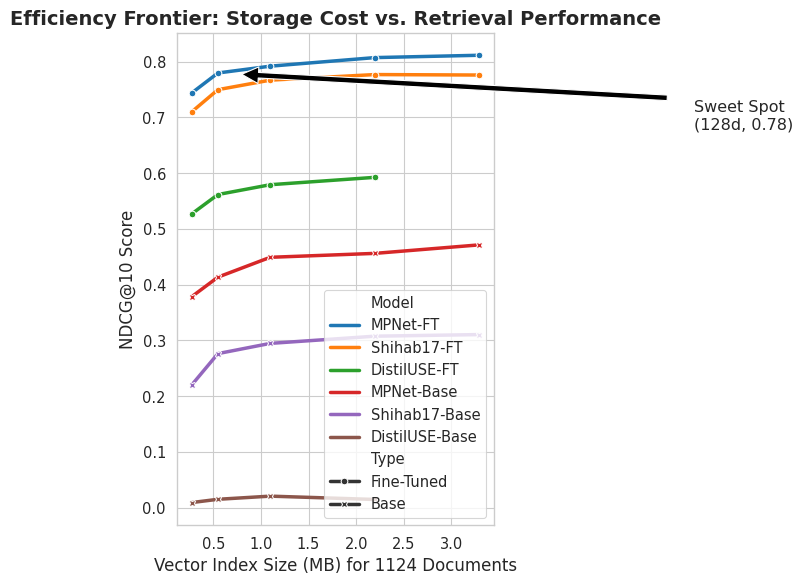

             Model  Dimension  Storage_MB   NDCG@10  Retention%
0         MPNet-FT        768    3.292969  0.811404  100.000000
1         MPNet-FT        512    2.195312  0.807212   99.483410
2         MPNet-FT        256    1.097656  0.791815   97.585879
3         MPNet-FT        128    0.548828  0.779632   96.084381
4         MPNet-FT         64    0.274414  0.743845   91.673891
5      Shihab17-FT        768    3.292969  0.775945   99.890972
6      Shihab17-FT        512    2.195312  0.776792  100.000000
7      Shihab17-FT        256    1.097656  0.766781   98.711240
8      Shihab17-FT        128    0.548828  0.749696   96.511790
9      Shihab17-FT         64    0.274414  0.710025   91.404818
10    DistilUSE-FT        512    2.195312  0.592512  100.000000
11    DistilUSE-FT        256    1.097656  0.579298   97.769849
12    DistilUSE-FT        128    0.548828  0.561689   94.797916
13    DistilUSE-FT         64    0.274414  0.527015   88.945996
14      MPNet-Base        768    3.29296

In [6]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sentence_transformers.evaluation import InformationRetrievalEvaluator
import gc

# ==========================================
# 1. SETUP MODELS & DIMENSIONS
# ==========================================
# REPLACE with your actual HuggingFace Model IDs
MODEL_MAP = {
    # Fine-Tuned Models
    "MPNet-FT": "Kowshik24/bangla-sentence-transformer-ft-matryoshka-paraphrase-multilingual-mpnet-base-v2",
    "Shihab17-FT": "Kowshik24/bangla-sentence-transformer-ft-matryoshka",
    "DistilUSE-FT": "Kowshik24/bangla-sentence-transformer-ft-matryoshka-distiluse-base-multilingual-cased-v1",

    # Base Models
    "MPNet-Base": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "Shihab17-Base": "shihab17/bangla-sentence-transformer",
    "DistilUSE-Base": "sentence-transformers/distiluse-base-multilingual-cased-v1"
}

# Dimensions to test
DIMS = [768, 512, 256, 128, 64]
CORPUS_SIZE = len(corpus) # Calculated from previous cell (should be around ~10k docs)

results_data = []

# ==========================================
# 2. RUN EXPERIMENT
# ==========================================
print(f"Calculating efficiency for Corpus Size: {CORPUS_SIZE} documents")

for model_name, model_id in MODEL_MAP.items():
    print(f"\nProcessing: {model_name}...")
    try:
        model = SentenceTransformer(model_id, device=device)
        model_max_dim = model.get_sentence_embedding_dimension()

        # Run evaluation for each dimension
        for dim in DIMS:
            # Skip dimensions larger than model capacity (e.g., DistilUSE is max 512)
            if dim > model_max_dim:
                continue

            # 1. Calculate Storage Size (Float32 = 4 bytes)
            # Size in MB = (Num_Docs * Dim * 4 bytes) / (1024 * 1024)
            storage_mb = (CORPUS_SIZE * dim * 4) / (1024 ** 2)

            # 2. Evaluate Accuracy (NDCG@10)
            # We use the evaluator's truncate_dim feature
            ir_eval = InformationRetrievalEvaluator(
                queries=queries,
                corpus=corpus,
                relevant_docs=relevant_docs,
                name=f"eval_{dim}",
                truncate_dim=dim,
                score_functions={"cosine": util.cos_sim}
            )

            scores = ir_eval(model)
            ndcg_score = scores[f"eval_{dim}_cosine_ndcg@10"]

            # Store Result
            results_data.append({
                "Model": model_name,
                "Type": "Fine-Tuned" if "-FT" in model_name else "Base",
                "Architecture": model_name.split("-")[0],
                "Dimension": dim,
                "Storage_MB": storage_mb,
                "NDCG@10": ndcg_score
            })

            print(f"  Dim: {dim}d | Size: {storage_mb:.2f}MB | NDCG: {ndcg_score:.4f}")

        # Cleanup to save RAM
        del model
        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"Failed to load {model_name}: {e}")

# ==========================================
# 3. VISUALIZE TRADE-OFF
# ==========================================
df_eff = pd.DataFrame(results_data)

# Calculate "Relative Efficiency"
# (How much % accuracy do we keep vs Max Dim?)
# We assume Max Dim is the best performance for that model
df_eff['Retention%'] = 0.0
for model in df_eff['Model'].unique():
    max_score = df_eff[df_eff['Model']==model]['NDCG@10'].max()
    df_eff.loc[df_eff['Model']==model, 'Retention%'] = (df_eff['NDCG@10'] / max_score) * 100

# Plot
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 6))

# We plot Storage (X) vs Performance (Y)
sns.lineplot(
    data=df_eff,
    x="Storage_MB",
    y="NDCG@10",
    hue="Model",
    style="Type",
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette="tab10",
    ax=ax
)

# Invert X axis? No, we want Low Storage (Left) to High Storage (Right)
# But we want to show that Left is Good.

ax.set_title("Efficiency Frontier: Storage Cost vs. Retrieval Performance", fontsize=14, fontweight='bold')
ax.set_xlabel(f"Vector Index Size (MB) for {CORPUS_SIZE} Documents", fontsize=12)
ax.set_ylabel("NDCG@10 Score", fontsize=12)

# Annotate the "Sweet Spot" (e.g., MPNet 128d)
# Find MPNet-FT 128d row
sweet_spot = df_eff[(df_eff['Model']=="MPNet-FT") & (df_eff['Dimension']==128)].iloc[0]
ax.annotate(f"Sweet Spot\n(128d, {sweet_spot['NDCG@10']:.2f})",
            xy=(sweet_spot['Storage_MB'], sweet_spot['NDCG@10']),
            xytext=(sweet_spot['Storage_MB']+5, sweet_spot['NDCG@10']-0.1),
            arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.savefig("efficiency_tradeoff.png", dpi=300)
plt.show()

# Display Table
print(df_eff[['Model', 'Dimension', 'Storage_MB', 'NDCG@10', 'Retention%']])

In [7]:
df_eff.head()

,Model,Type,Architecture,Dimension,Storage_MB,NDCG@10,Retention%
0,MPNet-FT,Fine-Tuned,MPNet,768,3.292969,0.811404,100.000000
1,MPNet-FT,Fine-Tuned,MPNet,512,2.195312,0.807212,99.483410
2,MPNet-FT,Fine-Tuned,MPNet,256,1.097656,0.791815,97.585879
3,MPNet-FT,Fine-Tuned,MPNet,128,0.548828,0.779632,96.084381
4,MPNet-FT,Fine-Tuned,MPNet,64,0.274414,0.743845,91.673891


In [8]:
df_eff.to_csv("efficiency_of_model_ft_and_base.csv",index=False)